# Level 2: The Core Water Balance Model (Vectorized)

## 2.1 The Mathematical Objective
To simulate the daily moisture availability across the farm, we rely on the discrete soil-water balance model. The core equation governing this system is:

$$S_{t+1} = S_t + P_t + I_t - ET_t - D_t$$

**Where:**
* $S$: Soil Moisture (%)
* $P$: Precipitation / Rainfall (mm)
* $I$: Irrigation Applied (Control Variable, mm)
* $ET$: Evapotranspiration (System Loss, mm)
* $D$: Drainage (System Loss, mm)

## 2.2 Computational Approach
Because calculating this equation row-by-row using Python `for` loops introduces severe computational bottlenecks, this level implements **NumPy Vectorization**. By processing arrays at the C-language level, we can calculate $ET$ and $D$ for thousands of temporal records simultaneously.

In [1]:
import pandas as pd
import numpy as np

def calculate_water_balance(df):
    """
    Executes vectorized water loss calculations (Evapotranspiration and Drainage)
    across the entire farm timeline simultaneously, matching the Level 1 empirical formula.
    """
    print("Initializing Vectorized Water Balance Engine...")

    # 1. Convert Pandas columns to fast NumPy arrays (Using NEW column names)
    temps = df['temperature_c'].to_numpy()
    humidity = df['humidity_pct'].to_numpy()
    wind = df['wind_speed_mps'].to_numpy()
    solar = df['solar_index'].to_numpy()
    rain = df['rainfall_mm'].to_numpy()
    
    moisture = df['soil_moisture_pct'].to_numpy()
    field_capacity = df['field_capacity_pct'].to_numpy()
    drainage_coeff = df['drainage_coefficient'].to_numpy()

    # 2. Vectorized Evapotranspiration (ET) Approximation
    # Synchronized with the Level 1 formula
    et_raw = (0.12 * temps) + (0.35 * wind) + (2.4 * solar) - (0.025 * humidity)
    
    # Clip to 0.0 (soil cannot absorb water from the air in this model)
    et_daily = np.clip(et_raw, a_min=0.0, a_max=None) 

    # 3. Vectorized Drainage (D)
    excess_water = (moisture + rain) - field_capacity
    drainage_daily = np.where(excess_water > 0, excess_water * drainage_coeff, 0.0)

    # 4. Calculate S_(t+1) - The Projected Next Day Moisture
    projected_moisture = moisture + rain - et_daily - drainage_daily
    projected_moisture = np.clip(projected_moisture, a_min=0.0, a_max=None) # Hard lower bound of 0%

    # 5. Append calculated arrays back to the DataFrame (Colleague used 4 decimal places)
    df['estimated_ET_mm'] = np.round(et_daily, 4)
    df['estimated_drainage_mm'] = np.round(drainage_daily, 4)
    df['projected_moisture_pct'] = np.round(projected_moisture, 4)

    print("Vectorization Complete. Calculations applied at C-level speeds.")
    return df

data_path = '../data/processed/cleaned_irrigation_dataset.csv'
df = pd.read_csv(data_path)
result_df = calculate_water_balance(df)
df_simulated = calculate_water_balance(df.copy())  # Create a copy for simulation to avoid modifying the original DataFrame
display(df_simulated.head())

Initializing Vectorized Water Balance Engine...
Vectorization Complete. Calculations applied at C-level speeds.
Initializing Vectorized Water Balance Engine...
Vectorization Complete. Calculations applied at C-level speeds.


,date,zone_id,crop_type,soil_moisture_pct,tank_level_liters,pump_flow_lpm,pump_power_watts,sensor_status,rainfall_mm,temperature_c,...,wind_speed_mps,solar_index,area_m2,min_moisture_pct,target_moisture_pct,field_capacity_pct,drainage_coefficient,estimated_ET_mm,estimated_drainage_mm,projected_moisture_pct
0,2026-03-01,Zone_A,tomato,33.2,4829,18.8,437,OK,3.2,23.8,...,2.28,0.78,120,22,33,41,0.18,3.7835,0.0,32.6165
1,2026-03-01,Zone_B,kale,34.7,4728,22.1,461,OK,3.2,23.8,...,2.28,0.78,90,24,35,43,0.15,3.7835,0.0,34.1165
2,2026-03-01,Zone_C,maize,28.2,4515,25.7,490,OK,3.2,23.8,...,2.28,0.78,180,20,31,40,0.22,3.7835,0.0,27.6165
3,2026-03-02,Zone_A,tomato,36.1,4757,16.6,411,OK,2.2,25.9,...,1.62,0.71,120,22,33,41,0.18,3.8290,0.0,34.4710
4,2026-03-02,Zone_B,kale,32.0,4645,20.4,445,OK,2.2,25.9,...,1.62,0.71,90,24,35,43,0.15,3.8290,0.0,30.3710


## 2.4 Numerical Reliability & Error Analysis

In scientific computing, numbers are not absolute. Computers represent continuous real numbers using finite **floating-point arithmetic**, which inherently introduces rounding and truncation errors. 

### The Floating-Point Problem
For example, in standard IEEE 754 floating-point math, $0.1 + 0.2$ does not precisely equal $0.3$:

In [2]:
# Demonstrating the classic floating point representation error
float_sum = 0.1 + 0.2
print(f"0.1 + 0.2 = {float_sum}")
print(f"Does 0.1 + 0.2 == 0.3? {float_sum == 0.3}")

# To handle this in scientific computing, we use np.isclose() instead of '=='
print(f"Using np.isclose(0.1 + 0.2, 0.3): {np.isclose(float_sum, 0.3)}")

0.1 + 0.2 = 0.30000000000000004
Does 0.1 + 0.2 == 0.3? False
Using np.isclose(0.1 + 0.2, 0.3): True


### 2.5 Error Propagation Experiment
Beyond computer hardware limits, real-world IoT sensors have physical **measurement noise**. If our temperature sensor has an accuracy error of $\pm 0.5^\circ C$ and humidity has an error of $\pm 2.0\%$, how does that small hardware error propagate through our formulas and affect the final water loss calculation ($ET$)?

Running Synchronized Error Propagation Experiment...
Average ET Error introduced by complex sensor noise: ±0.076 mm/day


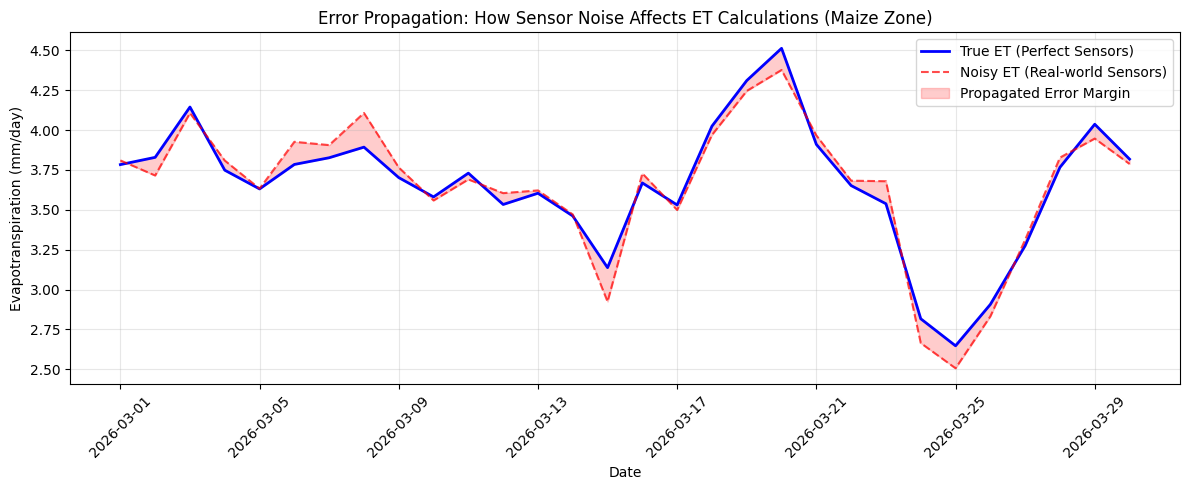

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Running Synchronized Error Propagation Experiment...")

# ==========================================
# 1. LOAD THE DATA 
# ==========================================
data_path = '../data/processed/cleaned_irrigation_dataset.csv'
df = pd.read_csv(data_path)
df['date'] = pd.to_datetime(df['date'])

# ==========================================
# 2. EXTRACT BASELINE (TRUE) VALUES
# ==========================================
df_maize = df[df['crop_type'] == 'maize'].copy()
df_maize = df_maize.sort_values('date') 

true_temp = df_maize['temperature_c'].to_numpy()
true_humidity = df_maize['humidity_pct'].to_numpy()
true_wind = df_maize['wind_speed_mps'].to_numpy()
true_solar = df_maize['solar_index'].to_numpy()

# Calculate 'True' ET matching Level 1
true_et = np.clip((0.12 * true_temp) + (0.35 * true_wind) + (2.4 * true_solar) - (0.025 * true_humidity), 0.0, None)

# ==========================================
# 3. SIMULATE HARDWARE SENSOR NOISE
# ==========================================
np.random.seed(42) 
noise_temp = np.random.normal(0, 0.5, len(true_temp))   # +/- 0.5 degree error
noise_humidity = np.random.normal(0, 2.0, len(true_humidity)) # +/- 2% humidity error
noise_wind = np.random.normal(0, 0.2, len(true_wind)) # +/- 0.2 m/s wind anemometer error

noisy_temp = true_temp + noise_temp
noisy_humidity = true_humidity + noise_humidity
noisy_wind = true_wind + noise_wind

# Calculate 'Noisy' ET with degraded sensor data
noisy_et = np.clip((0.12 * noisy_temp) + (0.35 * noisy_wind) + (2.4 * true_solar) - (0.025 * noisy_humidity), 0.0, None)

et_error = np.abs(noisy_et - true_et)
mean_et_error = np.mean(et_error)

print(f"Average ET Error introduced by complex sensor noise: ±{mean_et_error:.3f} mm/day")

# ==========================================
# 4. GENERATE THE PROPAGATION PLOT
# ==========================================
plt.figure(figsize=(12, 5))
plt.plot(df_maize['date'], true_et, label='True ET (Perfect Sensors)', color='blue', linewidth=2)
plt.plot(df_maize['date'], noisy_et, label='Noisy ET (Real-world Sensors)', color='red', linestyle='dashed', alpha=0.7)
plt.fill_between(df_maize['date'], true_et, noisy_et, color='red', alpha=0.2, label='Propagated Error Margin')

plt.title('Error Propagation: How Sensor Noise Affects ET Calculations (Maize Zone)')
plt.ylabel('Evapotranspiration (mm/day)')
plt.xlabel('Date')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig('error_propagation_plot.png', dpi=300)
plt.show()

In [4]:
# Save the Level 2 simulation results as a checkpoint for Level 3
output_path = '../data/processed/level_2_results.csv'
df_simulated.to_csv(output_path, index=False)
print(f"Level 2 Results successfully saved to {output_path}")

Level 2 Results successfully saved to ../data/processed/level_2_results.csv
